In [1]:
#importing the libraries 
import re
import numpy as np
import pandas as pd 
import networkx as nx
import matplotlib.pyplot as plt
from datasets import load_dataset
from collections import Counter

In [2]:
#laoding and preparing the data the data
corpus_data = load_dataset('allenai/scifact', 'corpus')
corpus_df = corpus_data['train'].to_pandas()

corpus_df['doc_id'] = corpus_df['doc_id'].astype(str).str.strip()

def normalize_text(text):
    if pd.isna(text) or text is None:
        return ''
    text = re.sub(r'[\r\n\t]+', ' ', str(text))
    return re.sub(r'\s+', ' ', text).strip()


def make_paragraph(abstract_list):
    if isinstance(abstract_list, (list, np.ndarray)):
        return ' '.join(str(s).strip() for s in abstract_list)
    return str(abstract_list).strip()


corpus_df['clean_title'] = corpus_df['title'].apply(normalize_text)
corpus_df['clean_abstract'] = corpus_df['abstract'].apply(make_paragraph).apply(normalize_text)
corpus_df['full_text'] = corpus_df['clean_title'] + ". " + corpus_df['clean_abstract']

print('Number of Documents: ', len(corpus_df))
corpus_df.head(2)

Number of Documents:  5183


,doc_id,title,abstract,structured,clean_title,clean_abstract,full_text
0,4983,Microstructural development of human newborn c...,[Alterations of the architecture of cerebral w...,False,Microstructural development of human newborn c...,Alterations of the architecture of cerebral wh...,Microstructural development of human newborn c...
1,5836,Induction of myelodysplasia by myeloid-derived...,[Myelodysplastic syndromes (MDS) are age-depen...,False,Induction of myelodysplasia by myeloid-derived...,Myelodysplastic syndromes (MDS) are age-depend...,Induction of myelodysplasia by myeloid-derived...


In [3]:
#Loading NLTK to select and remove the stopwords
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords', quiet=True)
english_stopwords = set(stopwords.words('english'))
english_stopwords

{'a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 "he's",
 'her',
 'here',
 'hers',
 'herself',
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 "i'll",
 "i'm",
 "i've",
 'if',
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [4]:
#filtering stopwords from original list
exception_words = {'about', 'above', 'after', 'again', 'against', 'are', "aren't", 'because', 'before', 'between', 'both', 'but', 'can', 'doing', 'during', 'each', 'few', 'having', 'how', 'if', 'into', 'no', 'nor', 'not', 'or', 'out', 'over', 'than', 'that', 'until', 'up', 'very'}
scientific_stopwords = english_stopwords - exception_words

def tokenize_for_graph(text):
    tokens = re.findall(r'\b[a-z0-9]+(?:-[a-z0-9]+)*\b', text.lower())
    clean_tokens = [t for t in tokens if t not in scientific_stopwords and len(t)>1]
    return clean_tokens



In [5]:
#function that implements the sliding window Graph of words construction function to generate nodes and weighted co-occurrence edges.
def build_graph_of_words(text, window_size = 3):
    tokens = tokenize_for_graph(text)
    G = nx.Graph()

    if len(tokens) == 0:
        return G

    for token in set(tokens):
        G.add_node(token)

    for i in range(len(tokens)):
        current_token = tokens[i]
        window_end = min(i + window_size, len(tokens))
        for j in range(i + 1, window_end):
            neighbor = tokens[j]
            if current_token != neighbor:
                if G.has_edge(current_token, neighbor):
                    G[current_token][neighbor]['weight'] += 1
                else:
                    G.add_edge(current_token, neighbor, weight=1)

    return G

test_sentence = "Alterations of the architecture of cerebral white-matter did not result in disabilities."
sample_graph = build_graph_of_words(test_sentence, window_size=3)
print(f"Sample Graph: {sample_graph.number_of_nodes()} nodes, {sample_graph.number_of_edges()} edges")
print("Edges with weights:")
for u, v, data in sample_graph.edges(data=True):
    print(f" {u}--{v} (weight: {data['weight']})")

Sample Graph: 7 nodes, 11 edges
Edges with weights:
 disabilities--not (weight: 1)
 disabilities--result (weight: 1)
 cerebral--alterations (weight: 1)
 cerebral--architecture (weight: 1)
 cerebral--white-matter (weight: 1)
 cerebral--not (weight: 1)
 white-matter--architecture (weight: 1)
 white-matter--not (weight: 1)
 white-matter--result (weight: 1)
 alterations--architecture (weight: 1)
 result--not (weight: 1)


In [6]:
#building the first Graoh of words using the first scientific paper in the corpus and evaluates basic network
doc_0 = corpus_df.iloc[0]
doc_0_id = doc_0['doc_id']
doc_0_title = doc_0['clean_title']
doc_0_text = doc_0['full_text']

G_doc_0 = build_graph_of_words(doc_0_text, window_size=3)

print("Document ID: ", doc_0_id)
print("Title: ", doc_0_title)
print(f"\nTotal Unique Concepts (Nodes): {G_doc_0.number_of_nodes()}")
print(f"Total Concept Links (Edges):  {G_doc_0.number_of_edges()}")
print(f"Graph Density:                 {nx.density(G_doc_0):.4f}")

Document ID:  4983
Title:  Microstructural development of human newborn cerebral white matter assessed in vivo by diffusion tensor magnetic resonance imaging.

Total Unique Concepts (Nodes): 110
Total Concept Links (Edges):  333
Graph Density:                 0.0555


In [7]:
#calculating Pagerank and weighted degree to rank most structurally significant concepts in the paper
pagerank_scores = nx.pagerank(G_doc_0, weight='weight')
degree_centrality = dict(G_doc_0.degree(weight='weight'))

concept_ranking_df = pd.DataFrame({
    'Concept': list(pagerank_scores.keys()),
    'PageRank': list(pagerank_scores.values()),
    'Weighted_Degree': [degree_centrality[k] for k in pagerank_scores.keys()]
}).sort_values(by='PageRank', ascending=False).reset_index(drop=True)

print('Top 15 most Important Concepts Indentified by Graph Structure: ')
concept_ranking_df.head(15)

Top 15 most Important Concepts Indentified by Graph Structure: 


,Concept,PageRank,Weighted_Degree
0,white,0.038794,40
1,matter,0.038788,40
2,diffusion,0.037127,34
3,infants,0.022634,22
4,term,0.022206,20
5,cerebral,0.020399,20
6,versus,0.019268,16
7,ms,0.018656,16
8,microm2,0.018620,16
9,tensor,0.018320,16


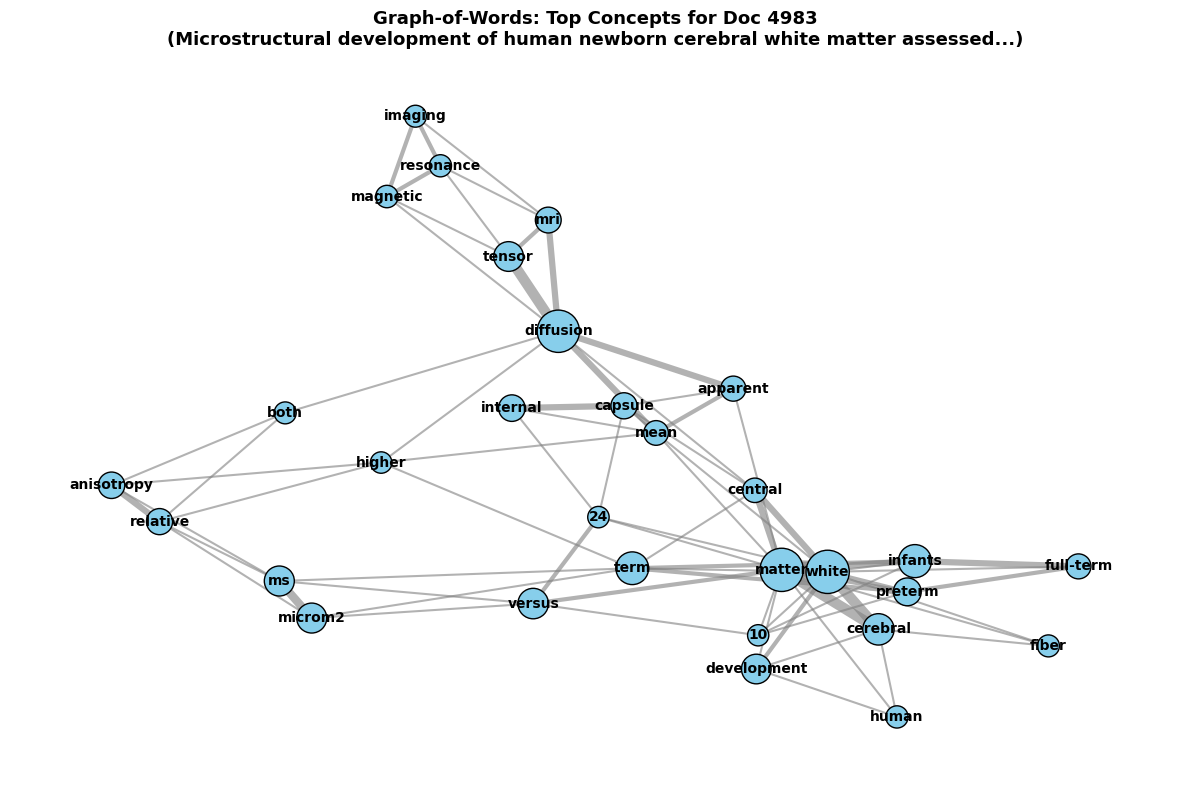

In [8]:
#visualization for the Graph of words with top 30 nodes
plt.figure(figsize=(12, 8))
top_nodes = concept_ranking_df['Concept'].head(30).tolist()
subgraph = G_doc_0.subgraph(top_nodes)

pos = nx.spring_layout(subgraph, k=0.5, seed=42)
node_sizes = [pagerank_scores[n] * 25000 for n in subgraph.nodes()]
edge_widths = [subgraph[u][v]['weight'] * 1.5 for u, v in subgraph.edges()]

nx.draw_networkx_nodes(subgraph, pos, node_size=node_sizes, node_color='skyblue', edgecolors='black')
nx.draw_networkx_edges(subgraph, pos, width=edge_widths, alpha=0.6, edge_color='gray')
nx.draw_networkx_labels(subgraph, pos, font_size=10, font_weight='bold')

plt.title(f"Graph-of-Words: Top Concepts for Doc {doc_0_id}\n({doc_0_title[:75]}...)", fontsize=13, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()

In [9]:
#Computes global graph topological properties, including total nodes, edge density, clustering coefficient, and connectivity.
num_nodes = G_doc_0.number_of_nodes()
num_edges = G_doc_0.number_of_edges()
density = nx.density(G_doc_0)
avg_clustering = nx.average_clustering(G_doc_0, weight='weight')

is_connected = nx.is_connected(G_doc_0)
num_components = nx.number_connected_components(G_doc_0)

print("Graph Topological Properties" + str(doc_0_id)+ ")")

print(f"\n\nTotal Nodes (|V|)           : {num_nodes}")
print(f"Total Edges (|E|)           : {num_edges}")
print(f"Graph Density               : {density:.4f}")
print(f"Average Clustering Coeff    : {avg_clustering:.4f}")
print(f"Is Fully Connected?         : {is_connected}")
print(f"Connected Components        : {num_components}")

Graph Topological Properties4983)


Total Nodes (|V|)           : 110
Total Edges (|E|)           : 333
Graph Density               : 0.0555
Average Clustering Coeff    : 0.0541
Is Fully Connected?         : True
Connected Components        : 1


In [10]:
#Compares topological pagerank against raw term frequency 
tokens_doc_0 = tokenize_for_graph(doc_0_text)
tf_counts = Counter(tokens_doc_0)

comparison_df = pd.DataFrame({
    'Concept': list(pagerank_scores.keys()),
    'PageRank': [pagerank_scores[k] for k in pagerank_scores.keys()],
    'Degree': [degree_centrality[k] for k in pagerank_scores.keys()],
    'Raw_Frequency': [tf_counts[k] for k in pagerank_scores.keys()]
})

for col in ['PageRank', 'Degree', 'Raw_Frequency']:
    comparison_df[col + '_Norm'] = comparison_df[col] / comparison_df[col].max()

comparison_df = comparison_df.sort_values(by='PageRank', ascending=False).reset_index(drop=True)

print("TOP 10 CONCEPTS: PAGERANK vs. RAW FREQUENCY")
comparison_df[['Concept', 'PageRank', 'Raw_Frequency', 'Degree']].head(10)

TOP 10 CONCEPTS: PAGERANK vs. RAW FREQUENCY


,Concept,PageRank,Raw_Frequency,Degree
0,white,0.038794,10,40
1,matter,0.038788,10,40
2,diffusion,0.037127,9,34
3,infants,0.022634,6,22
4,term,0.022206,5,20
5,cerebral,0.020399,5,20
6,versus,0.019268,4,16
7,ms,0.018656,4,16
8,microm2,0.018620,4,16
9,tensor,0.018320,4,16


In [11]:
#Runs a sensitivity analysis across sliding window sizes ($W \in \{2, 3, 5\}$) to quantify the impact of window size on graph edge density and concept ranking.

window_sizes = [2, 3, 5]
window_experiments = []

for w in window_sizes:
    G_w = build_graph_of_words(doc_0_text, window_size=w)
    pr_w = nx.pagerank(G_w, weight='weight')
    top_3_concepts = sorted(pr_w, key=pr_w.get, reverse=True)[:3]
    
    window_experiments.append({
        'Window_Size (W)': w,
        'Nodes': G_w.number_of_nodes(),
        'Edges': G_w.number_of_edges(),
        'Density': round(nx.density(G_w), 4),
        'Top_3_Concepts': ", ".join(top_3_concepts)
    })

window_exp_df = pd.DataFrame(window_experiments)

window_exp_df

EFFECT OF SLIDING WINDOW SIZE ON GRAPH TOPOLOGY


,Window_Size (W),Nodes,Edges,Density,Top_3_Concepts
0,2,110,158,0.0264,"matter, diffusion, white"
1,3,110,333,0.0555,"white, matter, diffusion"
2,5,110,668,0.1114,"white, matter, diffusion"


In [12]:
#exporting comparison result to CSV
import os
os.makedirs('results/tables', exist_ok=True)
window_exp_df.to_csv('results/tables/gow_window_sensitivity.csv', index=False)
comparison_df.head(15).to_csv('results/tables/gow_vs_tf_comparison.csv', index=False)

print("Artifacts successfully saved to results/tables/:")
print("  - gow_window_sensitivity.csv")
print("  - gow_vs_tf_comparison.csv")


Artifacts successfully saved to results/tables/:
  - gow_window_sensitivity.csv
  - gow_vs_tf_comparison.csv
